In [1]:
import torch 
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.functional as Fc
import matplotlib.pyplot as plt

In [2]:
train = torchvision.datasets.MNIST(root='./data', train=True, download=True)
test = torchvision.datasets.MNIST(root='./data', train=False, download=True)

print(train)
print(test)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test


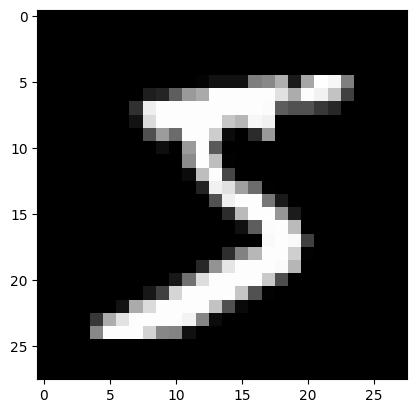

5


In [3]:
image, label = train[0]
plt.imshow(image, cmap='gray')
plt.show()

print(label)

In [4]:
transform = transforms.Compose([transforms.RandomInvert(), transforms.RandomRotation(45)])

train_transform = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_transform = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

In [5]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000)

In [20]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.w1 = nn.Parameter(torch.randn(28*28, 128) * 0.01)
        self.b1 = nn.Parameter(torch.zeros(128))
        self.w2 = nn.Parameter(torch.randn(128, 10) * 0.01)
        self.b2 = nn.Parameter(torch.randn(10))

    def forward(self, x):
        x = x.view(-1, 784)
        a1 =  x @ self.w1 + self.b1
        z1 = Fc.relu(a1)
        a2 = z1 @ self.w2 + self.b2
        return a2

In [21]:
def compute_error(pred, target):
    return Fc.cross_entropy(pred, target)

def compute_accuracy(pred, target):
    return (pred.argmax(dim=1) == target).float().mean().item()

In [27]:
def training(epochs=10, model=MLP()):
    model = model
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
    epochs = epochs

    for epoch in range(epochs):
        model.train()
        for image, label in train_loader:
            pred = model(image)
            loss = compute_error(pred, label)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        print(f'Epoch {epoch + 1} Loss {loss.item():.4f}')

In [26]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(784, 256)
        self.l2 = nn.Linear(256, 128)
        self.l3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        z1 = Fc.relu(self.l1(x))
        z2 = Fc.relu(self.l2(z1))
        out = self.l3(z2)
        return out

In [28]:
training()

Epoch 1 Loss 0.4209
Epoch 2 Loss 0.6761
Epoch 3 Loss 0.4118
Epoch 4 Loss 0.3529
Epoch 5 Loss 0.3796
Epoch 6 Loss 0.4013
Epoch 7 Loss 0.5218
Epoch 8 Loss 0.2711
Epoch 9 Loss 0.2360
Epoch 10 Loss 0.4480


In [49]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
model = MLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
epochs = 10
best_loss = float('inf')

for epoch in range(epochs):
    model.train()
    for image, label in train_loader:
        pred = model(image)
        loss = compute_error(pred, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        model.eval()
        total_loss = 0
        for image, label in test_loader:
            pred = model(image)
            total_loss += compute_error(pred, label).item()
        
        total_loss = total_loss / len(test_loader)

        if total_loss < best_loss:
            best_loss = total_loss
            torch.save(model.state_dict(), 'best_model.pth')

    print(f'Epoch: {epoch + 1}, Loss: {loss.item():.4f}, Val Loss: {total_loss:.4f}')

Epoch: 1, Loss: 0.0560, Val Loss: 0.1154
Epoch: 2, Loss: 0.0801, Val Loss: 0.0923
Epoch: 3, Loss: 0.1852, Val Loss: 0.1153
Epoch: 4, Loss: 0.0196, Val Loss: 0.0796
Epoch: 5, Loss: 0.0130, Val Loss: 0.0926
Epoch: 6, Loss: 0.0530, Val Loss: 0.0962
Epoch: 7, Loss: 0.0103, Val Loss: 0.0805
Epoch: 8, Loss: 0.0431, Val Loss: 0.0984
Epoch: 9, Loss: 0.0038, Val Loss: 0.1035
Epoch: 10, Loss: 0.0001, Val Loss: 0.1118


In [53]:
model.load_state_dict(torch.load('./best_model.pth'))
model.eval()
test_loss = 0
test_acc = 0

with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images)
        test_loss += compute_error(preds, labels).item()
        test_acc += compute_accuracy(preds, labels)

test_loss /= len(test_loader)
test_acc /= len(test_loader)

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0796, Test Accuracy: 0.9770


In [55]:
class SGD_Momentum:
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.lr= lr
        self.params = params
        self.momentum = momentum
        self.v = [torch.zeros_like(p) for p in params]

    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            self.v[i] = self.momentum * self.v + (1 - self.momentum) * p.grad
            self.params[i].data -= self.lr * self.v[i]

    def zero_grads(self):
        for p in self.params:
            p.grad = None

In [56]:
class Adam:
    def __init__(self, params, lr=0.01, betas=(0.9, 0.999), eps=1e-8):
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.params = params
        self.m = [torch.zeros_like(p.data) for p in self.params]
        self.v = [torch.zeros_like(p.data) for p in self.params]
        self.t = 0

    def step(self):
        t += 1
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue

            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * p.grad
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * p.grad *  p.grad

            m_hat = self.m[i] / (1 - (self.beta1 ** self.t))
            v_hat = self.v[i] / (1 - (self.beta2 ** self.t))

            p.data -= (self.lr / (v_hat + self.eps).sqrt()) * m_hat

    def zero_grads(self):
        for p in self.params:
            p.grad = None